# How fast can ESP accelerators get data from memory?

**A 16-tile ESP chip on an FPGA: 13 accelerators all pulling data from one memory
controller at once. Where does it jam, and does the multiOT change help?**

This is the short version. The full analysis, with every caveat and every counter traced to
the RTL, is in `characterization_report_4x4.ipynb`.

---

## The five results

**1. The memory is not the problem.** The DDR4 chip runs at **6%** of its capacity. Even at
the best point measured it never exceeds 11%.

**2. The bottleneck is the hand-off to the accelerators.** The memory tile can push out one
64-bit word per cycle; each accelerator can only take one word every *two* cycles. When the
memory tile is stuck serving a single accelerator, the whole chip runs at that one
accelerator's speed -- **13 accelerators deliver what 1 delivers**.

**3. How you chop up a transfer matters more than anything else.** Moving the same 6.8 MB,
the slowest setting takes **4.1x** longer than the fastest. And the fastest is in the middle:
neither the smallest nor the largest request size wins.

**4. multiOT is worth up to 3.1x**, and the benefit *grows* the more accelerators you run --
it was still climbing at 10. It does nothing at all with a single accelerator, and nothing
with very large requests.

**5. It costs up to 6.6% in one narrow case** -- two accelerators, write-heavy traffic, small
requests. Reproducibly.


In [1]:
# Colab bootstrap. A no-op anywhere else.
import os, sys, subprocess
REPO = "https://github.com/eugeniomuscinelli/esp-mem-characterization.git"
if "google.colab" in sys.modules and not os.path.isfile("charlib.py"):
    name = REPO.rsplit("/", 1)[-1].removesuffix(".git")
    if not os.path.isdir(name):
        subprocess.run(["git", "clone", "--depth", "1", "-q", REPO], check=True)
    os.chdir(name)


In [2]:
import warnings; warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt, pandas as pd, charlib as cl
plt.rcParams.update({"figure.dpi": 120, "font.size": 10, "figure.facecolor": "white"})
pd.set_option("display.width", 170)
arms = cl.load_all("4x4")
g = cl.occupancy_all(arms)
print(f"{len(arms)} hardware configurations, "
      f"{arms['baseline_ot1_gate0'].runs.run_id.nunique()} measured runs each, "
      f"0 errors, 0 timeouts")


3 hardware configurations, 504 measured runs each, 0 errors, 0 timeouts


---
# 1. The setup

## The chip

A 4x4 grid of tiles on a Xilinx VCU118 FPGA:

```
      +---------+---------+---------+---------+
      | MEMORY  |   CPU   |  acc 0  |  acc 1  |
      +---------+---------+---------+---------+
      |  acc 2  |  acc 3  |  acc 4  |  acc 5  |
      +---------+---------+---------+---------+
      |  acc 6  |  acc 7  |  acc 8  |  acc 9  |
      +---------+---------+---------+---------+
      | acc 10  | acc 11  | acc 12  |   IO    |
      +---------+---------+---------+---------+
```

**13 accelerators, one memory tile.** The tiles talk over an on-chip network. Caches are
switched off, so every byte an accelerator asks for is a real trip to DRAM.

The accelerators are traffic generators -- they do no computation. Their only job is to pull
data from memory in a pattern we control, so what gets measured is the memory path itself.

## The speeds that matter

Three numbers. Everything in this report is a fraction of one of them.

| | speed | |
|---|---|---|
| the **DRAM chip** | 10 GB/s | what the memory could deliver |
| the **port into it** | **1.25 GB/s** | what the chip is actually wired to use -- 8x narrower |
| **one accelerator** | 625 MB/s | what a single accelerator can swallow |

That middle number is the real ceiling: the memory tile sits behind a 64-bit connection
clocked at 156.25 MHz, so **one 64-bit word per cycle** is the most that can ever flow. The
DRAM behind it is eight times wider and is never close to being the limit.

The third number is half the second, because accelerators run at half the memory tile's clock
speed. That turns out to be the whole story.

## The three hardware configurations

Identical in every respect except one: how many memory requests the memory tile may have
in flight at the same time.

| | requests in flight |
|---|---|
| **baseline** -- stock ESP | 1 |
| **multiOT depth 2** | 2 |
| **multiOT depth 4** | 4 |


---
# 2. What the test does

**Every run moves exactly the same amount of data: 512 KB per accelerator.** With 13
accelerators that is 6.8 MB. This never changes.

What changes is **how the transfer is chopped up**. An accelerator doesn't ask for 512 KB in
one go -- it asks in instalments. Each instalment is a *request*: "give me N bytes starting
here". We sweep N from **64 bytes up to 128 KB**.

| request size | requests per accelerator |
|---|---|
| 64 bytes | 8,192 |
| 2 KB | 256 |
| 128 KB | **4** |

Same bytes moved, **2,048x difference in how many times the accelerator has to ask**. A
request costs the same to send whatever its size -- three small network packets -- so bigger
requests mean less asking.

We also sweep **how many accelerators run at once** (1, 2, 4, 6, 8, 10, 13) and **the mix of
reads and writes**.

That is 168 combinations, each repeated 3 times, for each of the three hardware
configurations -- 1,512 runs in total.


---
# 3. What we measure

Counters built into the chip, read before and after each run. These are the ones the results
below rest on.

| counter | what it counts |
|---|---|
| **read beats** | 8-byte chunks delivered from DRAM. The main measurement. |
| **elapsed cycles** | how long the run took |
| **read channel busy** | cycles with at least one memory request outstanding |
| **2+ requests in flight** | cycles with two or more outstanding -- this is how we confirm multiOT is actually doing something. Zero by design in the baseline. |
| **output buffer full** | cycles the memory tile had data ready and nowhere to put it |
| **inbound refused** | cycles the memory tile turned away an incoming request because it was busy |

Two warnings, because the names are misleading and this trips people up:

- ESP's built-in counter called **"DDR accesses" counts writes only**. Read traffic is
  invisible to it. We added a read counter, which is why reads can be reported at all.
- ESP's counter called **"NoC backpressure" is not backpressure** -- it counts cycles a packet
  was present on a link, which is traffic, not congestion.

A third, worth knowing: one of the counters we added was wired to the wrong signal in the
earlier 3x3 campaign and silently read zero. It is fixed here. The full report documents every
counter, what it actually samples, and what its name misleads you into thinking.


---
# 4. Results

## 4.1 Same data, different request size: who finishes first?

Every point below moves the identical 6.8 MB. Only the request size changes.


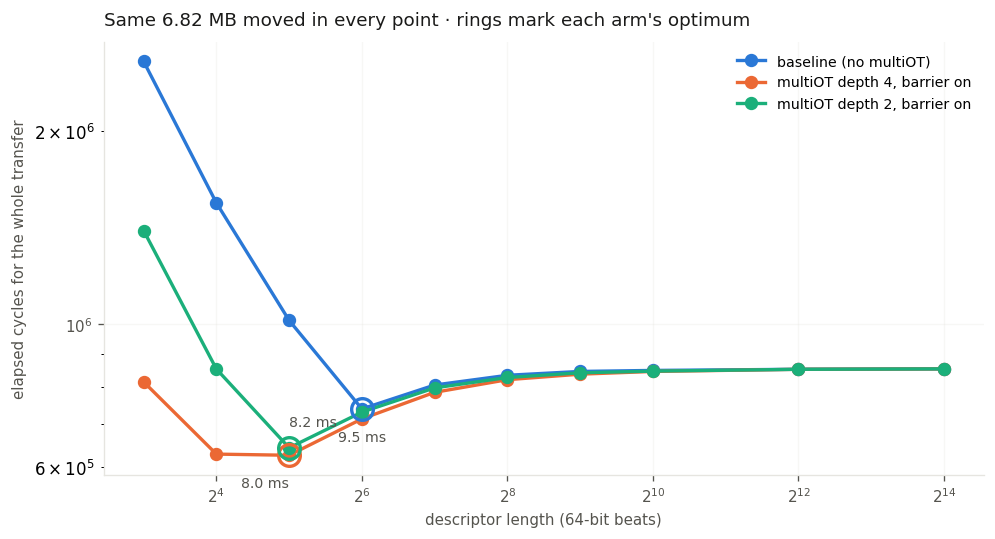

In [3]:
fig = cl.plot_elapsed(arms); plt.show()


**The fastest setting is in the middle, for every configuration.**

| | fastest at | time | slowest setting |
|---|---|---|---|
| baseline | **512-byte** requests | **9.5 ms** | 32.9 ms (3.5x worse) |
| multiOT depth 4 | **256-byte** requests | **8.0 ms** | 10.4 ms |

Across everything measured, the worst choice takes **4.1x** longer than the best, moving
identical data on identical hardware.

### Why there is a best in the middle

Two costs pull in opposite directions, and **every configuration pays both** -- which is why
even the baseline has a sweet spot rather than simply preferring the largest request.

**Small requests waste time waiting for DRAM.** For each request the memory tile sends an
address, waits for DRAM to answer, then collects the data. That wait is roughly the same
length whatever the request asked for -- about 47 cycles in the baseline. At 64-byte requests
the 13 accelerators issue 106,496 of them, so the chip spends **97% of the run waiting** and
3% moving data.

**Large requests stop the memory tile getting ahead.** The tile does not push data onto the
network directly -- it pushes into an **18-entry output queue** that drains on its own. A small
request fits in that queue: the tile drops it in and immediately starts the next request, which
belongs to a *different* accelerator, so two accelerators end up receiving at once. A 128 KB
request fills the queue after 18 entries out of 16,384, and from then on the tile can only push
as fast as that one accelerator receives. It is pinned to that accelerator for the rest of the
request, and nobody else gets anything.

**This output queue is the same 18 entries in all three configurations.** multiOT does not
change it -- multiOT shortens the *DRAM wait*, which is a different queue on the other side of
the memory tile. That is why multiOT helps only with small requests, and why all three
configurations behave identically once requests are large: there the DRAM wait has been
amortised away and the only thing left is the queue, which is the same in each.

The best size is where the two costs cross. Both are visible separately in the data:


In [4]:
rows = {}
for k in ("baseline_ot1_gate0", "multiot_ot4_gate1"):
    o = cl.occupancy(arms[k])
    s = o[(o.rd == 1) & (o.wr == 0) & (o.n_active == 13)].groupby("burst").mean(
        numeric_only=True)
    rate = s.ddr_read_beats / s.mem_cyc
    rows[(cl.LABEL[k].split(",")[0], "time per request (cycles)")] = (s.index/rate).round(0)
    rows[(cl.LABEL[k].split(",")[0], "output queue full (% of time)")] = (
        100*s.dma_snd_blocked/s.mem_cyc).round(1)
d = pd.DataFrame(rows); d.columns = pd.MultiIndex.from_tuples(d.columns)
d.index = [f"{b*8//1024} KB" if b*8 >= 1024 else f"{b*8} B" for b in d.index]
d.index.name = "request size"
d


baseline (no multiOT)                                         multiOT depth 4                              
             time per request (cycles) output queue full (% of time) time per request (cycles) output queue full (% of time)
request size                                                                                                                
64 B                              47.0                           0.0                      15.0                           0.0
128 B                             57.0                           0.0                      24.0                           0.0
256 B                             76.0                           0.0                      47.0                          10.3
512 B                            111.0                           2.2                     107.0                          27.6
1 KB                             242.0                          22.9                     236.0                          38.3
2 KB                             501.0                          34.8                     495.0                          44.0
4 KB                            1018.0                          40.0                    1010.0                          46.9
8 KB                            2046.0                          42.4                    2040.0                          48.1
32 KB                           8222.0                          44.2                    8222.0                          48.8
128 KB                         32945.0                          44.7                   32942.0                          49.5

At **64 bytes** the output queue never fills (0.0% in both configurations) -- only the DRAM
wait is acting. At **128 KB** the cost per request is identical in both configurations (32,945
against 32,942 cycles) -- the DRAM wait has vanished and only the queue is acting.

**multiOT only shortens the DRAM wait**, cutting it from 47 cycles to 15 by sending the next
request's address while still waiting for the previous one's data. It does nothing about the
output queue. That is why its best point sits at a *smaller* request size than the baseline's
-- cheaper requests mean you can afford more of them -- and why the two become identical once
requests get large.

## 4.2 The speedup


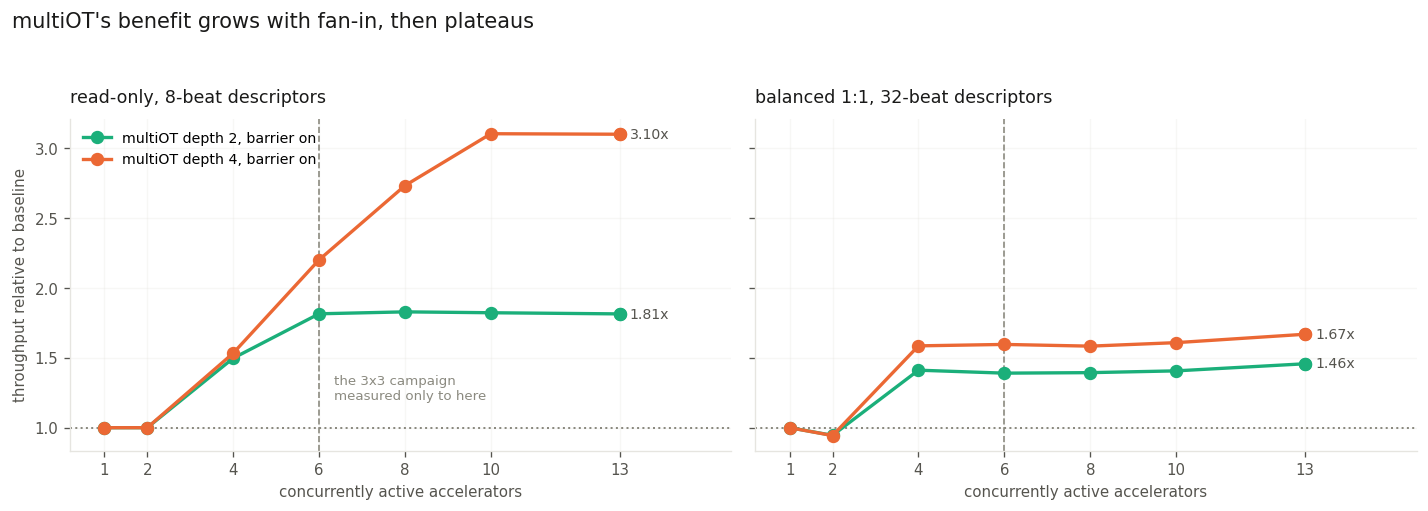

In [5]:
fig = cl.plot_speedup_vs_fanin(arms); plt.show()


**multiOT's benefit grows the more accelerators you run.** With small requests and read-only
traffic:

| accelerators | 1 | 2 | 4 | 6 | 8 | **10** | 13 |
|---|---|---|---|---|---|---|---|
| speedup | 1.0x | 1.0x | 1.5x | 2.2x | 2.7x | **3.1x** | 3.1x |

An earlier campaign on a smaller chip stopped at 6 accelerators and measured 2.2x. The effect
was still climbing.

**Three things it does not do:**

- **Nothing with one accelerator**, at any request size. The accelerator's own DMA engine is
  unchanged in all three configurations and only ever asks for one thing at a time, so there
  is nothing for the memory tile to overlap.
- **Nothing with large requests** -- exactly 1.000x at 32 KB and above.
- **It is slower in one narrow band**: up to **6.6%** with two accelerators, write-heavy
  traffic and 256-byte requests, in both multiOT configurations. Read-only traffic shows no
  such loss anywhere, which points at an interaction with writes. We have not identified the
  cause.

## 4.3 So where is the bottleneck?


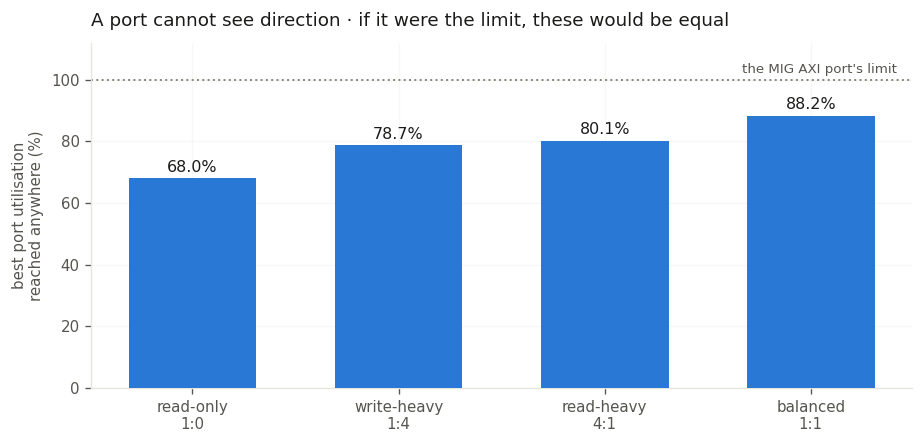

In [6]:
fig = cl.plot_peak_by_mix(arms); plt.show()


**Not the DRAM**, which never gets above 11% busy.

**Not the port into it either** -- it is idle half the time at large requests, and the best
point only reaches 88%.

And the chart above rules the port out properly: a port cannot tell a read from a write, so if
*it* were the limit all four bars would be the same height. They are not. Reads travel one
direction through the network and writes the other, so mixed traffic uses two separate paths
and gets more through. **That means the limit is per-direction, in the network, not at the
memory.**

What actually happens at large requests:


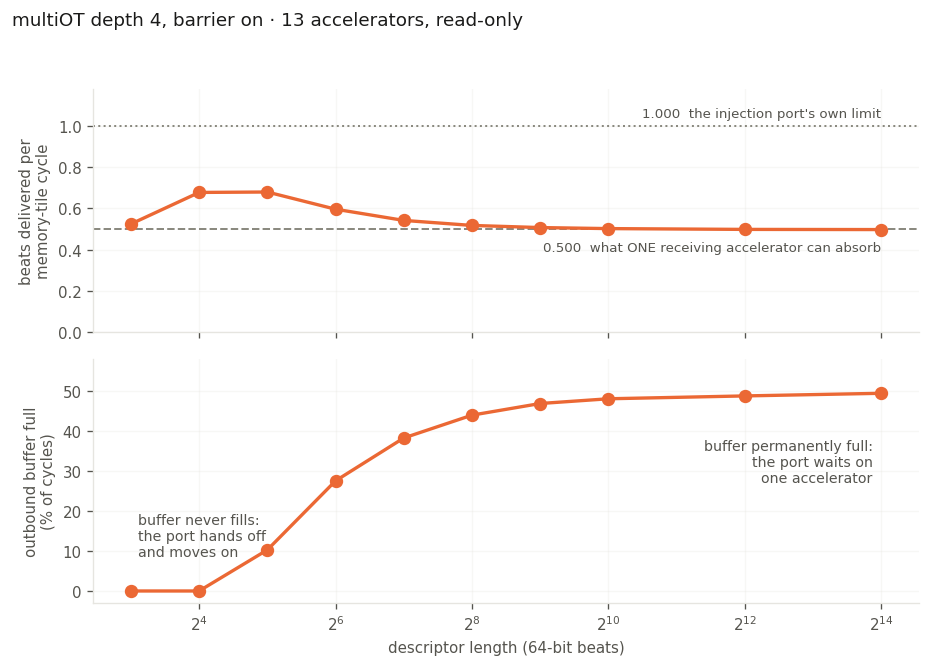

In [7]:
fig = cl.plot_handoff(arms); plt.show()


The memory tile can hand over a word every cycle. One accelerator can only swallow a word
every *two* cycles. In between sits a small buffer.

- **Small requests:** the memory tile dumps the whole request into the buffer faster than the
  accelerator drains it, then moves on to the next request -- which belongs to a *different*
  accelerator. Several accelerators drain at once, and the buffer never fills (top chart: 0%).
- **Large requests:** the buffer fills within the first few dozen words out of 16,384, and
  from then on the memory tile can only hand over as fast as that one accelerator swallows.
  Everyone else waits. The buffer is full half the time (bottom chart: 49.5%).

So at large requests the chip delivers 625 MB/s -- exactly one accelerator's worth -- no
matter whether 1 or 13 are running.


In [8]:
cl.per_accelerator_share(arms, burst=16384, rdg=1, wrg=0)[
    ["label", "n_active", "tot_beats_per_cyc"]].head(7)


,label,n_active,tot_beats_per_cyc
0,baseline (no multiOT),1,0.472515
1,baseline (no multiOT),2,0.486064
2,baseline (no multiOT),4,0.492600
3,baseline (no multiOT),6,0.494924
4,baseline (no multiOT),8,0.496215
5,baseline (no multiOT),10,0.496901
6,baseline (no multiOT),13,0.497616


---
# 5. What to take away

**If you are tuning an ESP system:** request size is the biggest lever available -- 4.1x
between the worst and best choice on identical hardware. The sweet spot here was 256-512 bytes.
Neither extreme is right.

**If you are deciding whether multiOT is worth it:** yes, where there are several accelerators
contending and requests are small. It gave 3.1x at 10 accelerators. It is worth nothing for a
single accelerator, and nothing for bulk transfers in large requests.

**If you are designing the next version:** the memory system is not the constraint -- it is
idle. The constraint is that one accelerator is served at a time while others wait, and that
an accelerator absorbs data at half the rate the memory tile can produce it. Those are the two
things worth attacking.

**A caveat worth stating:** the measurements at the largest request sizes carry up to 21%
launch stagger, because starting 13 accelerators takes the CPU a fixed amount of time that is
a big fraction of those short runs. The conclusions are not affected -- but a re-run should
move four times as much data per accelerator to make that disappear.

---

### The full report

`characterization_report_4x4.ipynb` has the complete analysis: every counter traced to its RTL
signal, what each one does *not* mean, the validation, what the campaign establishes against
what it merely suggests, and seven open questions with the experiment that would settle each.
